# 03 — Fourier: descoberta em 2023 e verificação em 2024

## Objetivo e divisão temporal
A prioridade do TCC é **prever a série temporal de tráfego**, com atenção aos picos. Fourier ajuda a identificar ciclos que podem orientar atributos e referências sazonais para a previsão. Investigar anomalias é um complemento opcional; valores altos não são excluídos automaticamente.

| Etapa | Dados | Papel neste notebook |
|---|---|---|
| Descoberta | 2023 | Identificar frequências candidatas usando somente o treino. |
| Verificação | 2024 | Examinar a persistência das frequências de 2023, mantendo o mesmo método. |
| Teste final | 2025 | Não participa dos cálculos ou gráficos deste notebook. |
| Complemento futuro | Janeiro de 2026 | Não participa desta análise. |


Analisamos médias horárias e máximos diários em etapas separadas. Uma frequência de 1 ciclo/dia corresponde a 24 horas; 1/7 ciclo/dia corresponde a 7 dias. Médias horárias suavizam eventos de cinco minutos e não substituem a série original para avaliar extremos.


O notebook utiliza a série processada pelo notebook 00, seleciona 2023–2024 e realiza verificações de cobertura, agregação temporal e tratamento de lacunas necessários à análise de Fourier.

Então temos uma sequência metodológica bastante coerente:
Welch médio de 2023
→ descobre candidatos.
Comparação 2023 × 2024
→ verifica se os candidatos aparecem também no outro ano.
Espectrograma dentro de cada ano
→ verifica se essas componentes são persistentes ao longo do tempo ou concentradas em determinados intervalos. Persistência espectral é evidência exploratória; ganho preditivo precisa ser validado em 2024.

Obs.: Revisões de qualidade dos dados e decisões metodológicas

Nela fazemos os diagnósticos de zeros, lacunas e máximo/P95/P99. Depois de tomarmos as decisões, limpamos essa seção: o que for apenas diagnóstico pode ser resumido ou removido, e as decisões definitivas passam a fazer parte do fluxo normal do notebook.



In [ ]:
# ------------------------------------------------------------
# importações, localização dos dados e parâmetros da análise.
# ------------------------------------------------------------


from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Funciona com o diretório de trabalho na raiz do projeto ou em notebooks/.
base_dir = next((p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / "data/processed/serie_temporal_filtrada_gbps.csv").exists()), None)
if base_dir is None:
    raise FileNotFoundError("Não foi encontrada a série processada do notebook 00.")
arquivo = base_dir / "data/processed/serie_temporal_filtrada_gbps.csv"

# Parâmetros exploratórios: não representam limites operacionais do IX.
ANO_TREINO = 2023
ANO_VALIDACAO = 2024
ANOS_ANALISE = (ANO_TREINO, ANO_VALIDACAO)
PAPEIS = {ANO_TREINO: "Descoberta", ANO_VALIDACAO: "Verificação"}
MIN_OBS_HORA = 9             # pelo menos 75% das 12 medições esperadas
MAX_LACUNA_HORAS = 3         # interpolar somente lacunas internas inteiras de até 3 h
MIN_OBS_DIA = 260            # pelo menos 90% das 288 medições esperadas
JANELA_DIAS = 28             # quatro ciclos semanais por janela espectral
PASSO_DIAS = 7
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True})

## 1. Leitura e qualidade temporal
A FFT exige amostragem regular. Ordenamos os timestamps e consolidamos duplicatas pela média, registrando quantas existem. Timestamps sem fuso não permitem distinguir com segurança registros repetidos de uma possível transição de horário de verão; essa consolidação é uma convenção exploratória, não uma correção comprovada.

A completude é recalculada contra o calendário inteiro, pois a presença de um ano no CSV filtrado não garante que ele esteja completo. Valores negativos ou não finitos são tratados como ausentes. Valores iguais a zero são inicialmente preservados para diagnóstico e seu tratamento é avaliado antes das análises espectrais.

O filtro 2023–2024 é aplicado imediatamente após a leitura, antes das estatísticas e do tratamento. As grades anuais são completas, incluindo possíveis ausências nas bordas. Cada ano é processado separadamente: a interpolação nunca usa valores do outro conjunto.

In [ ]:
# ------------------------------------------------------------
# Leitura da série, tratamento de inválidos e completude anual.
# ------------------------------------------------------------

df = pd.read_csv(arquivo, usecols=["datahora", "total_gbps"], parse_dates=["datahora"])
if df["datahora"].isna().any():
    raise ValueError("Há timestamps inválidos; revise a preparação dos dados.")
df = df.loc[df["datahora"].dt.year.isin(ANOS_ANALISE)].copy()
if set(df["datahora"].dt.year.unique()) != set(ANOS_ANALISE):
    raise ValueError("A base precisa conter os dois anos selecionados.")
valores = pd.to_numeric(df["total_gbps"], errors="coerce")
invalidos = (~np.isfinite(valores)) | (valores < 0)
df["total_gbps"] = valores.mask(invalidos)
duplicatas = int(df["datahora"].duplicated().sum())
serie = df.groupby("datahora")["total_gbps"].mean().sort_index()
assert set(serie.index.year) == set(ANOS_ANALISE)
print(f"Linhas selecionadas: {len(df):,} | timestamps duplicados: {duplicatas:,}")
print(f"Valores ausentes/inválidos no recorte: {invalidos.sum():,}")
print(f"Período: {serie.index.min()} até {serie.index.max()} | fuso: {serie.index.tz}")
qualidade = []
for ano in ANOS_ANALISE:
    s = serie.loc[serie.index.year == ano]
    inicio, fim = pd.Timestamp(ano, 1, 1), pd.Timestamp(ano + 1, 1, 1)
    esperado = int((fim - inicio) / pd.Timedelta(minutes=5))
    qualidade.append({"ano": ano, "papel": PAPEIS[ano], "observacoes_validas": s.count(),
                      "esperadas_calendario": esperado,
                      "completude_pct": 100 * s.count() / esperado})
qualidade = pd.DataFrame(qualidade).set_index("ano")
display(qualidade.round(2))

Linhas selecionadas: 210,528 | timestamps duplicados: 0
Valores ausentes/inválidos no recorte: 4,669
Período: 2023-01-01 00:02:29 até 2024-12-31 23:57:29 | fuso: None


,papel,observacoes_validas,esperadas_calendario,completude_pct
ano,,,,
2023,Descoberta,104668,105120,99.57
2024,Verificação,101191,105408,96.00


## 2. Séries regulares e tratamento das lacunas
Criamos médias horárias e máximos diários. Uma hora com menos de nove medições válidas é considerada ausente. Interpolamos apenas lacunas horárias internas de até três horas; lacunas maiores permanecem ausentes. Para os picos diários, exigimos 260 medições válidas (90% das 288 esperadas) e **não interpolamos máximos**.

A análise por janelas rejeita qualquer janela que ainda contenha ausência. Não juntamos os dois lados de uma lacuna, pois isso alteraria o tempo físico. Mostramos também o resultado sem interpolação, para avaliar sua influência. As contagens de cobertura usam dias de 24 horas; transições locais de horário de verão podem afetá-las.

Resumo:
Esta seção transforma a série de 5 minutos em duas séries adequadas ao problema — uma horária para estudar ciclos regulares e outra de máximos diários para estudar comportamento dos picos — e trata pequenas lacunas sem inventar valores em períodos longos.

Pendência:
 O principal ponto que ficou para corrigirmos depois da revisão completa é mesmo o tratamento de total_gbps == 0 como inválido.

 O máximo diário tem uma fragilidade óbvia: basta um único valor aberrante entre as 288 medições do dia para o máximo ficar completamente distorcido. Isso parece especialmente relevante no seu gráfico, onde aparecem alguns picos muito acima do comportamento típico. Considerar p95.

 Não substituiria silenciosamente o máximo agora. Metodologicamente, faria algo mais forte: manteria três séries na exploração inicial: 
 
maximo_diario
p95_diario representa cerca dos 14 maiores pontos.
p99_diario : representa os 3 maiores pontos do dia
Não tratar automaticamente valores altos como erro; comparar máximo, P99 e P95 e decidir qual estatística representa melhor o conceito de pico usado no trabalho.


,horas_calendario,horas_ausentes_antes,horas_interpoladas,horas_ausentes_depois,dias_sem_pico_valido
ano,,,,,
2023,8760,34,24,10,3
2024,8784,198,179,19,19


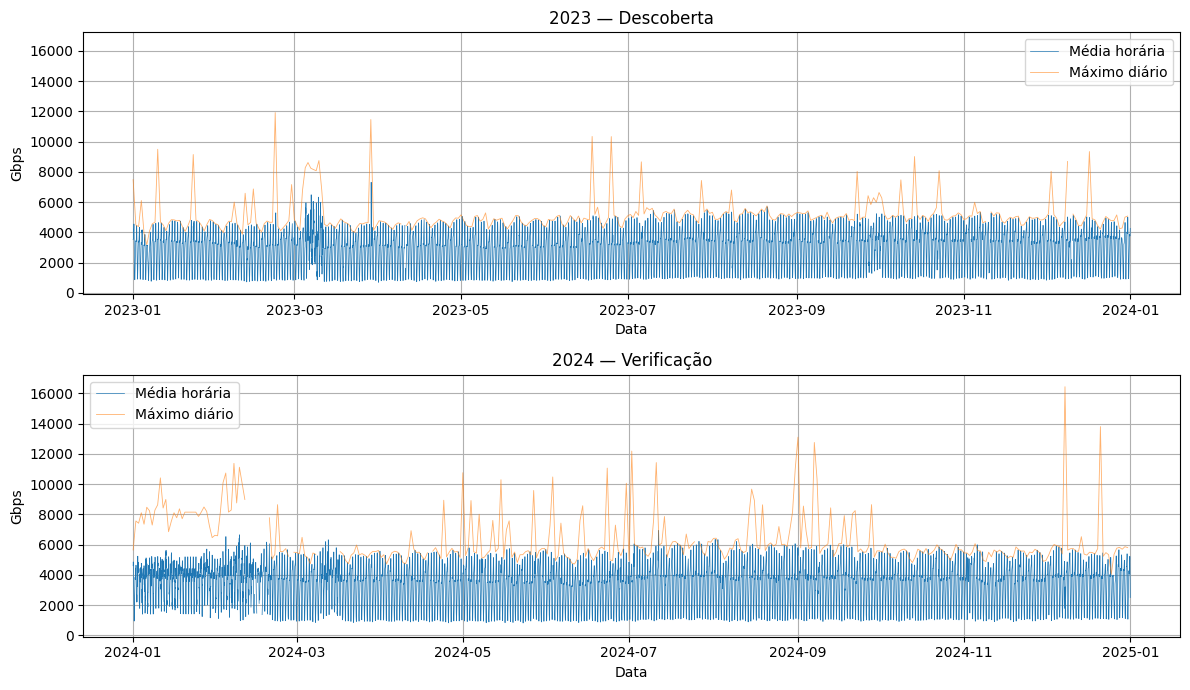

In [ ]:
# ------------------------------------------------------------
# Agrega médias horárias e máximos diários, interpola lacunas curtas e exibe séries e cobertura.
# ------------------------------------------------------------

def interpolar_lacunas_curtas(s, limite):
    ausente = s.isna()
    grupos = ausente.ne(ausente.shift()).cumsum()
    tamanhos = ausente.groupby(grupos).transform("sum")
    candidatos = s.interpolate(method="time", limit_area="inside")
    preencher = ausente & tamanhos.le(limite) & candidatos.notna()
    resultado = s.copy()
    resultado.loc[preencher] = candidatos.loc[preencher]
    return resultado, preencher

series_anuais = {}
cobertura = []
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharey=True)
for ax, ano in zip(axes, ANOS_ANALISE):
    s = serie.loc[serie.index.year == ano]
    inicio, fim = pd.Timestamp(ano, 1, 1), pd.Timestamp(ano + 1, 1, 1)
    grade_h = pd.date_range(inicio, fim, freq="h", inclusive="left")
    grade_d = pd.date_range(inicio, fim, freq="D", inclusive="left")
    horas = s.resample("h").agg(["mean", "count"]).reindex(grade_h)
    original = horas["mean"].where(horas["count"] >= MIN_OBS_HORA)
    horaria, interpoladas = interpolar_lacunas_curtas(original, MAX_LACUNA_HORAS)
    dias = s.resample("D").agg(["max", "count"]).reindex(grade_d)
    picos = dias["max"].where(dias["count"] >= MIN_OBS_DIA)
    series_anuais[ano] = {"original": original, "horaria": horaria, "picos": picos,
                          "interpoladas": interpoladas}
    cobertura.append({"ano": ano, "horas_calendario": len(horaria),
                      "horas_ausentes_antes": int(original.isna().sum()),
                      "horas_interpoladas": int(interpoladas.sum()),
                      "horas_ausentes_depois": int(horaria.isna().sum()),
                      "dias_sem_pico_valido": int(picos.isna().sum())})
    ax.plot(horaria.index, horaria, linewidth=.5, label="Média horária")
    ax.plot(picos.index, picos, linewidth=.6, alpha=.6, label="Máximo diário")
    ax.set(title=f"{ano} — {PAPEIS[ano]}", ylabel="Gbps", xlabel="Data")
    ax.legend()
display(pd.DataFrame(cobertura).set_index("ano"))
plt.tight_layout()
plt.show()

Gráfico de 2023 — Descoberta

A linha azul é a média horária. O aspecto de “dentes” muito regulares é importante: o tráfego sobe e desce repetidamente ao longo dos dias.
Isso sugere visualmente uma sazonalidade intradiária forte. Em outras palavras, existe um padrão que parece se repetir aproximadamente a cada 24 horas. É justamente o tipo de estrutura que esperamos que apareça posteriormente no espectro de Fourier.
Também parece existir uma evolução mais lenta do nível da série ao longo do ano. Por exemplo, o patamar observado em partes do segundo semestre não é exatamente igual ao do início do ano. Isso é diferente da oscilação diária: podemos ter simultaneamente ciclos rápidos + mudanças de nível de longo prazo.
A linha laranja é o máximo diário. Na maior parte do tempo ela acompanha aproximadamente a parte superior da série azul, mas aparecem alguns valores muito maiores, como aproximadamente 10–12 mil Gbps.

Gráfico de 2024 — Verificação

A oscilação azul continua extremamente visível em 2024.
Esse é um resultado preliminar interessante porque a estrutura visual observada em 2023 parece continuar existindo no ano seguinte.
Mas ainda não devemos escrever no TCC que “a periodicidade de 24 h foi confirmada”. O gráfico apenas fornece evidência visual. A análise espectral é que vai quantificar as frequências dominantes.
Há também algo diferente em 2024: a linha laranja apresenta descontinuidades.
Isso está diretamente relacionado à tabela:
19 dias não possuem máximo diário considerado válido.
Portanto, os buracos da linha laranja não significam dias sem tráfego. Significam:
nesses dias não havia pelo menos 260 das 288 medições válidas exigidas pelo critério adotado.

Essa distinção é muito importante.

Ressalva sobre picoss enormes de 2024

Há valores próximos de 13 mil, 14 mil e até 16 mil Gbps, enquanto a maior parte da série está muito abaixo disso.
Neste momento há pelo menos duas explicações possíveis:
evento real de tráfego ou erro/artefato de medição.
O gráfico sozinho não permite distinguir.

Mas repare em uma característica: alguns desses picos parecem extremamente estreitos. Se forem causados por uma única observação de cinco minutos, o máximo diário é muito sensível a eles.

Por isso que a exploração de P99/P95 pode ser bastante importante.

Resumo:As séries horárias de 2023 e 2024 apresentam uma oscilação intradiária pronunciada e visualmente persistente, motivando a investigação espectral das periodicidades dominantes. A série de máximos diários apresenta observações extremas pontuais e, sobretudo em 2024, descontinuidades decorrentes do critério mínimo de cobertura. Esses aspectos justificam analisar separadamente a estrutura periódica da série horária e o comportamento dos valores elevados.

Duas pendências metodológicas que identificamos durante a revisão: tratar total_gbps == 0 como erro de medição e comparar máximo diário × P99 × P95 para decidir qual representação de pico é mais apropriada.




## 3. Diagnóstico e decisões pendetes de qualidade e completude de dados.

In [18]:
# ------------------------------------------------------------
# 3.1 Diagnóstico de valores iguais a zero
# ------------------------------------------------------------

zeros = serie.eq(0)

resumo_zeros = []

for ano in ANOS_ANALISE:
    m_ano = serie.index.year == ano
    s_ano = serie.loc[m_ano]
    z_ano = s_ano.eq(0)

    resumo_zeros.append({
        "ano": ano,
        "observacoes": len(s_ano),
        "zeros": int(z_ano.sum()),
        "zeros_pct": 100 * z_ano.mean()
    })

display(pd.DataFrame(resumo_zeros).set_index("ano").round(4))

print(f"Total de valores iguais a zero no recorte: {int(zeros.sum())}")

,observacoes,zeros,zeros_pct
ano,,,
2023,105120,0,0.0
2024,105408,0,0.0


Total de valores iguais a zero no recorte: 0


**Valores iguais a zero: não foram encontrados valores total_gbps = 0 no recorte de 2023–2024. Portanto, não foi necessário definir tratamento específico para zeros nesta análise**

In [19]:
# ------------------------------------------------------------
# 3.2 Diagnóstico das lacunas horárias residuais
# ------------------------------------------------------------

lacunas_horarias = []

for ano in ANOS_ANALISE:
    s = series_anuais[ano]["horaria"]
    ausente = s.isna()

    grupos = ausente.ne(ausente.shift()).cumsum()

    for _, bloco in s[ausente].groupby(grupos[ausente]):
        inicio = bloco.index.min()
        fim = bloco.index.max()

        lacunas_horarias.append({
            "ano": ano,
            "inicio": inicio,
            "fim": fim,
            "duracao_horas": len(bloco)
        })

lacunas_horarias_df = pd.DataFrame(lacunas_horarias)

if len(lacunas_horarias_df):
    display(lacunas_horarias_df)
else:
    print("Nenhuma lacuna horária residual.")

,ano,inicio,fim,duracao_horas
0,2023,2023-04-10 12:00:00,2023-04-10 15:00:00,4
1,2023,2023-12-10 13:00:00,2023-12-10 18:00:00,6
2,2024,2024-02-14 13:00:00,2024-02-14 18:00:00,6
3,2024,2024-02-15 10:00:00,2024-02-15 13:00:00,4
4,2024,2024-02-16 07:00:00,2024-02-16 10:00:00,4
5,2024,2024-02-17 03:00:00,2024-02-17 07:00:00,5


In [20]:
# ------------------------------------------------------------
# 3.2.1 Lacunas horárias antes da interpolação
# ------------------------------------------------------------

lacunas_originais = []

for ano in ANOS_ANALISE:
    s = series_anuais[ano]["original"]
    ausente = s.isna()

    grupos = ausente.ne(ausente.shift()).cumsum()

    for _, bloco in s[ausente].groupby(grupos[ausente]):
        inicio = bloco.index.min()
        fim = bloco.index.max()
        duracao = len(bloco)

        lacunas_originais.append({
            "ano": ano,
            "inicio": inicio,
            "fim": fim,
            "duracao_horas": duracao,
            "interpolada_regra_atual": duracao <= MAX_LACUNA_HORAS
        })

lacunas_originais_df = pd.DataFrame(lacunas_originais)

display(lacunas_originais_df)

,ano,inicio,fim,duracao_horas,interpolada_regra_atual
0,2023,2023-03-24 22:00:00,2023-03-24 22:00:00,1,True
1,2023,2023-04-10 12:00:00,2023-04-10 15:00:00,4,False
2,2023,2023-04-10 18:00:00,2023-04-10 18:00:00,1,True
3,2023,2023-04-10 20:00:00,2023-04-10 21:00:00,2,True
4,2023,2023-04-17 15:00:00,2023-04-17 15:00:00,1,True
...,...,...,...,...,...
166,2024,2024-11-24 21:00:00,2024-11-24 21:00:00,1,True
167,2024,2024-11-25 21:00:00,2024-11-25 21:00:00,1,True
168,2024,2024-11-28 14:00:00,2024-11-28 14:00:00,1,True
169,2024,2024-12-17 14:00:00,2024-12-17 14:00:00,1,True


In [21]:
# ------------------------------------------------------------
# Resumo das lacunas originais
# ------------------------------------------------------------

resumo_lacunas = (
    lacunas_originais_df
    .groupby("ano")
    .agg(
        numero_lacunas=("duracao_horas", "count"),
        horas_ausentes=("duracao_horas", "sum"),
        menor_lacuna_h=("duracao_horas", "min"),
        mediana_lacuna_h=("duracao_horas", "median"),
        maior_lacuna_h=("duracao_horas", "max"),
        lacunas_interpoladas=("interpolada_regra_atual", "sum")
    )
)

display(resumo_lacunas)

,numero_lacunas,horas_ausentes,menor_lacuna_h,mediana_lacuna_h,maior_lacuna_h,lacunas_interpoladas
ano,,,,,,
2023,22,34,1,1.0,6,20
2024,149,198,1,1.0,6,145


In [ ]:
# ------------------------------------------------------------
# Compara a cobertura horária com limites de interpolação de 3 h e 6 h.
# ------------------------------------------------------------

comparacao_interpolacao = []

for ano in ANOS_ANALISE:
    original = series_anuais[ano]["original"]

    for limite in [3, 6]:
        serie_teste, preenchidas = interpolar_lacunas_curtas(
            original,
            limite
        )

        comparacao_interpolacao.append({
            "ano": ano,
            "limite_horas": limite,
            "horas_interpoladas": int(preenchidas.sum()),
            "horas_ausentes_depois": int(serie_teste.isna().sum()),
            "completude_horaria_pct": 100 * serie_teste.notna().mean()
        })

comparacao_interpolacao_df = pd.DataFrame(comparacao_interpolacao)

display(
    comparacao_interpolacao_df
    .set_index(["ano", "limite_horas"])
    .round(4)
)

horas_interpoladas  horas_ausentes_depois  \
ano  limite_horas                                              
2023 3                             24                     10   
     6                             34                      0   
2024 3                            179                     19   
     6                            198                      0   

                   completude_horaria_pct  
ano  limite_horas                          
2023 3                            99.8858  
     6                           100.0000  
2024 3                            99.7837  
     6                           100.0000

In [23]:
# ------------------------------------------------------------
# Compara os maiores trechos contínuos de 2023 após interpolação de até 3 h e 6 h.
# ------------------------------------------------------------

def maior_trecho_temp(s):
    """Retorna o maior trecho contínuo sem valores ausentes."""
    valido = s.notna()
    grupos = valido.ne(valido.shift()).cumsum()

    trechos = [
        bloco
        for _, bloco in s[valido].groupby(grupos[valido])
    ]

    if not trechos:
        return s.iloc[0:0]

    return max(trechos, key=len)


ano = ANO_TREINO
original = series_anuais[ano]["original"]

series_teste = {}

for limite in [3, 6]:

    serie_interp, preenchidas = interpolar_lacunas_curtas(
        original,
        limite
    )

    trecho = maior_trecho_temp(serie_interp)

    print(
        f"Limite {limite} h: "
        f"{int(preenchidas.sum())} horas interpoladas | "
        f"maior trecho = {len(trecho)} horas "
        f"({len(trecho) / 24:.1f} dias) | "
        f"{trecho.index.min()} até {trecho.index.max()}"
    )

    series_teste[limite] = {
        "serie": serie_interp,
        "trecho": trecho
    }

Limite 3 h: 24 horas interpoladas | maior trecho = 5853 horas (243.9 dias) | 2023-04-10 16:00:00 até 2023-12-10 12:00:00
Limite 6 h: 34 horas interpoladas | maior trecho = 8760 horas (365.0 dias) | 2023-01-01 00:00:00 até 2023-12-31 23:00:00


A regra de interpolação de até três horas mantém 10 horas ausentes em 2023, distribuídas em apenas duas lacunas de 4 e 6 horas. Essas lacunas fazem com que a FFT utilize somente o maior trecho contínuo, de 243,9 dias. Ao ampliar experimentalmente o limite para seis horas, a série horária de 2023 torna-se completa, com 365 dias.

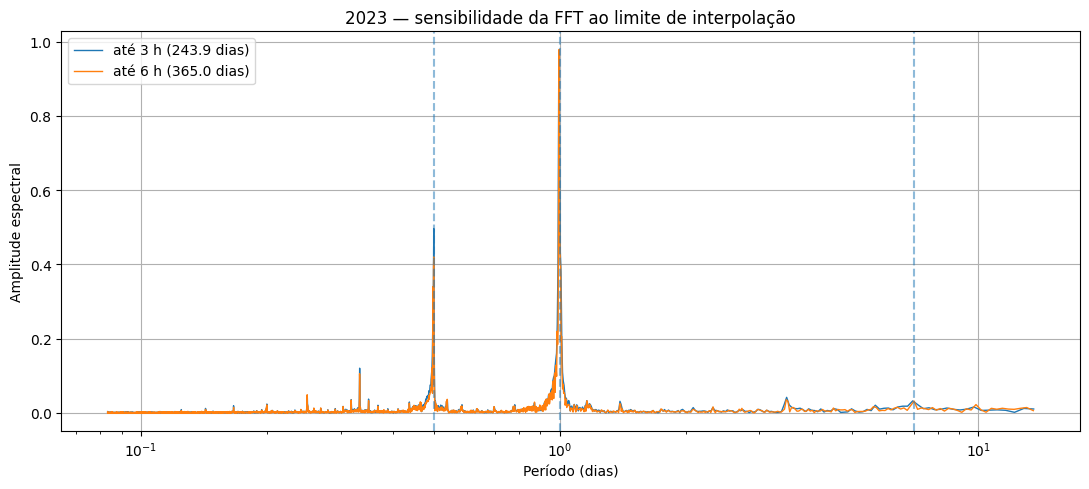

In [24]:
# ------------------------------------------------------------
# Calcula e plota a FFT de 2023 com limites de interpolação de 3 h e 6 h.
# ------------------------------------------------------------

# *** precisa das funcoes espectro_fft e preparar_sinal definidas na próxima seção.


fig, ax = plt.subplots(figsize=(11, 5))

resultados_fft_sensibilidade = {}

for limite in [3, 6]:

    trecho = series_teste[limite]["trecho"]

    freq, amplitude = espectro_fft(
        trecho,
        dt_dias=1 / 24
    )

    # Remove frequência zero
    mascara = freq > 0

    periodo_dias = 1 / freq[mascara]
    amp = amplitude[mascara]

    # Faixa de interesse: 2 horas a 14 dias
    faixa = (
        (periodo_dias >= 2 / 24) &
        (periodo_dias <= 14)
    )

    resultados_fft_sensibilidade[limite] = {
        "freq": freq,
        "amplitude": amplitude,
        "periodo_dias": periodo_dias,
        "amp": amp
    }

    ax.plot(
        periodo_dias[faixa],
        amp[faixa],
        linewidth=1,
        label=(
            f"até {limite} h "
            f"({len(trecho) / 24:.1f} dias)"
        )
    )

ax.axvline(1, linestyle="--", alpha=.5)
ax.axvline(0.5, linestyle="--", alpha=.5)
ax.axvline(7, linestyle="--", alpha=.5)

ax.set_xscale("log")

ax.set(
    xlabel="Período (dias)",
    ylabel="Amplitude espectral",
    title=(
        "2023 — sensibilidade da FFT "
        "ao limite de interpolação"
    )
)

ax.legend()
plt.tight_layout()
plt.show()

Primeiro, o pico de 1 dia (24 h) permanece praticamente no mesmo lugar e com amplitude muito semelhante. Portanto, a principal periodicidade que identificamos em 2023 não parece ser consequência da regra de interpolação de 3 horas.
Segundo, a componente de 0,5 dia (12 h) também permanece claramente presente. Há alguma diferença de amplitude entre as curvas, mas não uma mudança na conclusão qualitativa: ela continua sendo uma componente importante do espectro.
Terceiro, na região de 7 dias, as curvas também apresentam estrutura semelhante e de amplitude muito pequena comparada às componentes intradiárias. Portanto, usar o ano completo não transforma o ciclo semanal em uma componente dominante na série horária.

In [25]:
# ------------------------------------------------------------
# Comparação dos principais picos da FFT com limites de interpolação de 3 h e 6 h
# ------------------------------------------------------------

tabelas_sensibilidade = {}

for limite in [3, 6]:
    r = resultados_fft_sensibilidade[limite]

    tabela = tabela_picos(
        r["freq"],
        r["amplitude"],
        periodo_min=2 / 24,   # 2 horas
        periodo_max=14,       # 14 dias
        top=8
    )

    tabelas_sensibilidade[limite] = tabela

    print(
        f"\nPrincipais picos — interpolação até {limite} h "
        f"({len(series_teste[limite]['trecho']) / 24:.1f} dias)"
    )

    display(tabela.round(4))


Principais picos — interpolação até 3 h (243.9 dias)


,frequencia_ciclos_dia,periodo_dias,periodo_horas,intensidade_espectral
0,1.0046,0.9954,23.8898,0.9269
1,1.9969,0.5008,12.0185,0.4968
2,3.0015,0.3332,7.9959,0.1206
3,1.0456,0.9564,22.9529,0.0642
4,2.0502,0.4878,11.7060,0.0600
5,1.0620,0.9416,22.5985,0.0499
6,2.0625,0.4848,11.6362,0.0472
7,4.0062,0.2496,5.9908,0.0456



Principais picos — interpolação até 6 h (365.0 dias)


,frequencia_ciclos_dia,periodo_dias,periodo_horas,intensidade_espectral
0,1.0027,0.9973,23.9344,0.9790
1,1.9973,0.5007,12.0165,0.4201
2,2.0055,0.4986,11.9672,0.3404
3,1.0137,0.9865,23.6757,0.2203
4,0.9890,1.0111,24.2659,0.2063
5,1.0219,0.9786,23.4853,0.1285
6,2.0137,0.4966,11.9184,0.1227
7,1.0274,0.9733,23.3600,0.1076


In [ ]:
# ------------------------------------------------------------
# 3.2.3.2 Comparação nos períodos de interesse
# ------------------------------------------------------------

periodos_alvo_horas = [24, 12, 8, 6]

comparacao_componentes = []

for periodo_horas in periodos_alvo_horas:

    freq_alvo = 24 / periodo_horas  # ciclos/dia

    linha = {
        "periodo_alvo_horas": periodo_horas
    }

    for limite in [3, 6]:
        r = resultados_fft_sensibilidade[limite]

        idx = np.argmin(
            np.abs(r["freq"] - freq_alvo)
        )

        linha[f"periodo_bin_{limite}h_horas"] = (
            24 / r["freq"][idx]
        )

        linha[f"amplitude_{limite}h"] = (
            r["amplitude"][idx]
        )

    comparacao_componentes.append(linha)

display(
    pd.DataFrame(comparacao_componentes).round(4)
)


,periodo_alvo_horas,periodo_bin_3h_horas,amplitude_3h,periodo_bin_6h_horas,amplitude_6h
0,24,23.9877,0.7740,24.0,0.4820
1,12,11.9939,0.3502,12.0,0.3937
2,8,7.9959,0.1206,8.0,0.0867
3,6,5.9969,0.0410,6.0,0.0046


A ampliação experimental do limite de interpolação de três para seis horas permite utilizar todo o ano de 2023, em vez de apenas o maior trecho contínuo de 243,9 dias. A comparação dos espectros preserva as principais componentes próximas de 24 e 12 horas, indicando que essas estruturas não dependem da regra mais restritiva de interpolação. Componentes de menor intensidade apresentam maior sensibilidade ao intervalo analisado e devem ser interpretadas com mais cautela.

**As lacunas horárias residuais são curtas e têm duração máxima de seis horas. Com o limite conservador de três horas, permanecem 10 horas ausentes em 2023 e 19 em 2024. Uma análise de sensibilidade com limite de seis horas completa ambas as séries horárias e preserva as principais componentes espectrais de 24 e 12 horas, indicando que as conclusões principais não dependem da regra mais restritiva.**

## 3.3. Critério final de completude diária

Adotamos **90% de completude: pelo menos 260 das 288 observações diárias**. A revisão em 2024 recupera dias com lacunas curtas distribuídas ao longo do dia; a robustez típica dos máximos é semelhante à dos dias já aceitos por 95%. Completude não garante que o verdadeiro pico tenha sido observado, e máximos isolados também ocorrem em dias bem cobertos. Não interpolamos máximos nem removemos extremos automaticamente.

| Evidência em 2024 | `valido_95` | `recuperado_90` | `invalido_90` |
|---|---:|---:|---:|
| Dias | 284 | 63 | 19 |
| Observações ausentes — mediana | 6,00 | 18,00 | 65,00 |
| Maior bloco ausente — mediana (min) | 10,00 | 15,00 | 25,00 |
| Maior bloco ausente — máximo (min) | 30,00 | 25,00 | 40,00 |
| Segundo máximo/máximo — mediana (%) | 99,43 | 99,45 | 98,98 |
| Dias com segundo máximo/máximo < 90% | 36/284 (12,68%) | 12/63 (19,05%) | 3/19 (15,79%) |

A semelhança das medianas não implica distribuições iguais: a frequência de razões abaixo de 90% é maior nos dias recuperados. Esses casos permanecem nos dados e requerem interpretação separada da completude.

A tabela resume os diagnósticos reproduzíveis em [03a_daily_completeness_sensitivity.ipynb](03a_daily_completeness_sensitivity.ipynb), incluindo as frequências de máximos isolados e o caso exploratório de 2024-09-28. A decisão está registrada em [DECISOES_RECORTE_TEMPORAL.md](../DECISOES_RECORTE_TEMPORAL.md).

**Welch horário:** independe de `MIN_OBS_DIA`; conserva o critério horário e a interpolação de até 3 h. **Welch dos máximos diários:** usa `picos`, construído com o critério diário de 90%, e seus resultados são recalculados abaixo. A definição do pico como máximo, P95 ou P99 permanece uma decisão separada.


## 4. Preparação espectral e funções
Aplicamos `log1p` para reduzir o efeito de diferenças de escala e de valores muito altos, sem apagar eventos. Removemos uma tendência linear e padronizamos cada trecho/janela. Os espectros descrevem **a distribuição relativa da variabilidade**, não a magnitude dos picos em Gbps.

Uma janela de Hann reduz o espalhamento de energia causado pelas bordas. A FFT usa o maior trecho contínuo disponível. A estimativa de Welch faz a média dos periodogramas de janelas regulares válidas com sobreposição; a densidade é unilateral e normalizada pela energia da janela.

Com dados horários, o menor período representável é 2 horas. Com janelas de 28 dias, a resolução é 1/28 ciclo/dia; estudamos períodos até 14 dias para observar pelo menos dois ciclos por janela. Picos próximos de 12 ou 8 horas podem ser harmônicos do ciclo diário, não ciclos independentes. Esta configuração **não testa sazonalidade anual**.

Cada janela é padronizada localmente para comparar formas espectrais, sem ajustar uma escala conjunta entre treino e validação. Esse processamento retrospectivo não é um pipeline de previsão: no futuro modelo, transformações aprendidas devem ser ajustadas apenas no treino.

In [13]:
# ------------------------------------------------------------
# Define funções de preparação do sinal, FFT, espectros por janelas e comparação de candidatos.
# ------------------------------------------------------------

def maior_trecho(s):
    valido = s.notna()
    grupos = valido.ne(valido.shift()).cumsum()
    tamanhos = valido.groupby(grupos).sum()
    if tamanhos.empty or tamanhos.max() == 0:
        raise ValueError("Série sem trecho válido.")
    return s.loc[grupos.eq(tamanhos.idxmax())]

def preparar_sinal(valores):
    y = np.log1p(np.asarray(valores, dtype=float))
    if not np.isfinite(y).all():
        raise ValueError("O trecho espectral contém valores inválidos.")
    t = np.linspace(-1, 1, len(y))
    y = y - np.polyval(np.polyfit(t, y, 1), t)
    escala = y.std()
    return y / escala if escala > 1e-12 else np.zeros_like(y)

def espectro_fft(s, dt_dias):
    y = preparar_sinal(s.to_numpy())
    w = np.hanning(len(y))
    freq = np.fft.rfftfreq(len(y), d=dt_dias)
    amplitude = np.abs(np.fft.rfft(y * w)) / w.sum()
    amplitude[1:] *= 2
    if len(y) % 2 == 0:
        amplitude[-1] /= 2
    return freq, amplitude

def espectros_janelas(s, dt_dias=1/24, janela_dias=JANELA_DIAS, passo_dias=PASSO_DIAS):
    n = int(round(janela_dias / dt_dias))
    passo = int(round(passo_dias / dt_dias))
    if n < 4 or passo < 1:
        raise ValueError("Janela ou passo insuficiente.")
    if len(s) > 1:
        esperado = pd.Timedelta(days=dt_dias)
        if not (s.index.to_series().diff().dropna() == esperado).all():
            raise ValueError("Índice temporal não regular.")
    w = np.hanning(n)
    freq = np.fft.rfftfreq(n, d=dt_dias)
    espectros, centros, validas = [], [], []
    for inicio in range(0, len(s) - n + 1, passo):
        trecho = s.iloc[inicio:inicio+n]
        centros.append(trecho.index[n//2])
        ok = trecho.notna().all()
        validas.append(ok)
        if not ok:
            espectros.append(np.full(len(freq), np.nan))
            continue
        y = preparar_sinal(trecho.to_numpy())
        psd = np.abs(np.fft.rfft(y * w))**2 * dt_dias / (w**2).sum()
        psd[1:] *= 2
        if n % 2 == 0:
            psd[-1] /= 2
        espectros.append(psd)
    if not espectros:
        raise ValueError("Série menor que a janela espectral.")
    return freq, np.asarray(espectros).T, pd.DatetimeIndex(centros), np.asarray(validas)

def tabela_picos(freq, potencia, periodo_min, periodo_max, top=8):
    indices = np.arange(1, len(freq)-1)
    indices = indices[(potencia[indices] > potencia[indices-1]) & (potencia[indices] >= potencia[indices+1])]
    indices = indices[(1/freq[indices] >= periodo_min) & (1/freq[indices] <= periodo_max)]
    indices = indices[np.argsort(potencia[indices])[::-1]][:top]
    return pd.DataFrame({"frequencia_ciclos_dia": freq[indices],
                         "periodo_dias": 1/freq[indices],
                         "periodo_horas": 24/freq[indices],
                         "intensidade_espectral": potencia[indices]})

def referencias(ax, unidade="dias"):
    for dias, nome in [(0.5, "12 h"), (1, "24 h"), (7, "7 dias")]:
        ax.axvline(dias if unidade == "dias" else 24*dias, linestyle="--", alpha=.5, label=nome)

def comparar_candidatos(candidatos, resultados, coluna_freq="frequencia_ciclos_dia"):
    # Os candidatos vêm exclusivamente de 2023; 2024 não gera novos candidatos.
    linhas = []
    for _, candidato in candidatos.iterrows():
        alvo = candidato[coluna_freq]
        linha = {"periodo_candidato_horas": 24/alvo}
        for ano in ANOS_ANALISE:
            r = resultados[ano]
            f, p = r["freq"], r["psd"]
            j = int(np.argmin(np.abs(f-alvo)))
            faixa = (f >= r["freq_min"]) & (f <= r["freq_max"])
            banda = faixa & (np.abs(f-alvo) <= (f[1]-f[0])*1.01)
            total = p[faixa].sum()
            linha[f"periodo_bin_{ano}_horas"] = 24/f[j]
            linha[f"maximo_local_{ano}"] = bool(0 < j < len(p)-1 and p[j] > p[j-1] and p[j] >= p[j+1])
            linha[f"potencia_banda_{ano}_pct"] = 100*p[banda].sum()/total if total > 0 else np.nan
        linhas.append(linha)
    return pd.DataFrame(linhas)


## 5. Descoberta: FFT do tráfego horário de 2023


A FFT usa somente o maior trecho contínuo de 2023. A tabela lista máximos locais do espectro, não anomalias no tempo. O período efetivamente coberto é mostrado; não extrapolamos automaticamente suas conclusões para o ano inteiro. As linhas de referência de 12 h, 24 h e 7 dias são hipóteses de calendário, não resultados presumidos.

FFT de 2023: 2023-04-10 16:00:00 até 2023-12-10 12:00:00 (243.9 dias)


,frequencia_ciclos_dia,periodo_dias,periodo_horas,intensidade_espectral
0,1.0046,0.9954,23.8898,0.9269
1,1.9969,0.5008,12.0185,0.4968
2,3.0015,0.3332,7.9959,0.1206
3,1.0456,0.9564,22.9529,0.0642
4,2.0502,0.4878,11.7060,0.0600
5,1.0620,0.9416,22.5985,0.0499
6,2.0625,0.4848,11.6362,0.0472
7,4.0062,0.2496,5.9908,0.0456


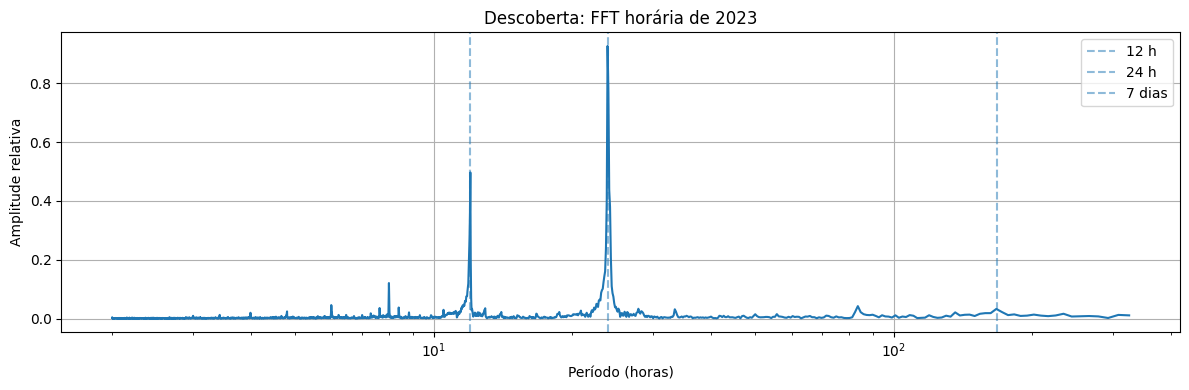

In [14]:
# ------------------------------------------------------------
# Calcula e plota a FFT do maior trecho horário contínuo de 2023 e lista seus picos.
# ------------------------------------------------------------

trecho_treino = maior_trecho(series_anuais[ANO_TREINO]["horaria"])
if len(trecho_treino) < 24 * 56:
    raise ValueError("Menos de 56 dias horários contínuos no treino; revise a cobertura.")
f_fft, a_fft = espectro_fft(trecho_treino, 1/24)
print(f"FFT de {ANO_TREINO}: {trecho_treino.index.min()} até {trecho_treino.index.max()} ({len(trecho_treino)/24:.1f} dias)")
picos_fft_treino = tabela_picos(f_fft, a_fft, 2/24, 14)
display(picos_fft_treino.round(4))
m = (f_fft >= 1/14) & (f_fft <= 12)
fig, ax = plt.subplots()
ax.semilogx(24/f_fft[m], a_fft[m])
referencias(ax, "horas")
ax.set(xlabel="Período (horas)", ylabel="Amplitude relativa", title=f"Descoberta: FFT horária de {ANO_TREINO}")
ax.legend()
plt.tight_layout()
plt.show()

A FFT aplicada ao maior trecho horário contínuo de 2023, correspondente a aproximadamente 244 dias entre abril e dezembro, apresenta uma componente dominante próxima de 24 horas. Também aparecem picos próximos de 12, 8 e 6 horas, compatíveis com harmônicos do ciclo diário e indicativos de que o padrão intradiário não possui forma puramente senoidal. A componente próxima de sete dias é visualmente muito menos intensa e deverá ser examinada nas análises espectrais por janelas.


**Ressalvas metodológicas e pontos pendentes**
A utilização de aproximadamente 244 dias na FFT global não deve ser considerada, neste momento, uma necessidade técnica. Esse recorte é consequência da regra conservadora adotada para o tratamento das lacunas, e não uma exigência matemática inevitável da análise.
Antes da conclusão do notebook, deve-se examinar a localização e a duração das 10 horas que permanecem ausentes em 2023. A partir dessa análise, será avaliada a possibilidade de uma interpolação adicional controlada, comparando-se o espectro resultante com aquele obtido atualmente a partir do maior trecho contínuo.
A escolha metodológica também não se restringe às alternativas de interpolar todas as lacunas ou descartar os períodos que impedem a formação de uma série anual contínua. A análise por janelas, realizada posteriormente no notebook, permite trabalhar com diferentes trechos válidos da série sem exigir continuidade ao longo de todo o ano.
Portanto, o uso dos 244 dias deve ser entendido como resultado de uma decisão metodológica conservadora. Considerando que apenas 10 horas ausentes levam à exclusão de aproximadamente 121 dias da FFT global, é necessário avaliar se a perda de informação decorrente dessa escolha é proporcional ao benefício obtido ao evitar uma interpolação adicional.

Para o fechamento da revisão do notebook, permanecem os seguintes pontos:

- avaliar o uso do máximo diário em comparação com P95 e P99;
- investigar as 10 horas ausentes em 2023 e avaliar uma interpolação controlada, comparando a FFT de uma série próxima ao ano completo com a FFT atual baseada em aproximadamente 244 dias;
- avaliar a denominação do eixo Y do espectro, considerando “Amplitude relativa” ou “Amplitude espectral”.
- verificar a análise de sensibilidade sem interpolação em 2024, pois apenas 1 de 49 janelas é válida. Nessas condições, ela não é diretamente comparável ao espectro com interpolação, que utiliza 45 janelas. Precisamos decidir se a mantemos apenas como diagnóstico, se alteramos a estratégia de sensibilidade ou se a retiramos;
- confirmar exatamente onde ocorre a “normalização por janela” em espectros_janelas(). O código do espectrograma mostrado agora usa uma referência global — o máximo espectral de 2023 — e não realiza, nesse trecho, uma normalização individual de cada janela. Precisamos verificar a função para garantir que o texto “A normalização por janela compara formas, não crescimento absoluto em Gbps” descreve corretamente o procedimento.

## 6. Descoberta: Welch e candidatos identificados em 2023
A média de periodogramas usa janelas de 28 dias com passo de sete dias. Selecionamos até oito máximos locais na faixa de 2 horas a 14 dias **apenas em 2023**. São candidatos exploratórios, não uma seleção definitiva de atributos nem um teste de significância.

A curva sem interpolação avalia a sensibilidade ao preenchimento. Ela pode representar outras datas e menos janelas. As janelas sobrepostas não são observações independentes.




Rascunho de texto:

Aqui o objetivo já não é obter um único espectro de 2023, mas perguntar:
Quais periodicidades aparecem de forma suficientemente consistente ao longo de 2023 quando analisamos vários trechos menores da série?

É isso que o Welch por janelas está tentando capturar.
1. O que está sendo feito
Em vez de pegar toda a série de 2023 e calcular uma única FFT, o código divide 2023 em janelas de 28 dias, iniciando uma nova janela a cada 7 dias.
Esquematicamente:

```
Janela 1: dias  1 ─────────────────── 28
Janela 2:       dias 8 ─────────────────── 35
Janela 3:              dias 15 ────────────────── 42
Janela 4:                     dias 22 ────────────────── 49
                 ↑
            avanço de 7 dias
```


Portanto, as janelas se sobrepõem bastante. Isso é deliberado: cada trecho fornece uma estimativa do espectro, e depois essas estimativas são combinadas (média delas)

O preço disso é que as janelas são muito parecidas entre si: duas janelas consecutivas compartilham 21 dos seus 28 dias (75%). É justamente por isso que o texto alerta que as janelas sobrepostas não são observações independentes.

2. Por que isso é diferente da FFT anterior?
Na FFT global, uma lacuna não preenchida podia quebrar a continuidade da série e levar vocês a usar apenas o maior trecho contínuo — foi justamente daí que surgiu aquela questão dos aproximadamente 244 dias. Aqui a situação melhora bastante.
Como estamos trabalhando com janelas de apenas 28 dias, uma lacuna pode invalidar algumas janelas sem obrigatoriamente descartar uma enorme parte de 2023.
Então existem duas abordagens complementares:

FFT global: pergunta quais frequências dominam um grande trecho contínuo da série.
Welch/janelas: pergunta quais frequências aparecem, em média, nos vários períodos de 28 dias ao longo do ano.





2023: 42/49 janelas utilizadas.
Candidatos descobertos exclusivamente no treino:


,frequencia_ciclos_dia,periodo_dias,periodo_horas,intensidade_espectral
0,1.0000,1.0000,24.0000,13.0244
1,2.0000,0.5000,12.0000,3.7115
2,3.0000,0.3333,8.0000,0.1659
3,0.0714,14.0000,336.0000,0.0605
4,4.0000,0.2500,6.0000,0.0353
5,2.1429,0.4667,11.2000,0.0326
6,1.8571,0.5385,12.9231,0.0252
7,0.8571,1.1667,28.0000,0.0250


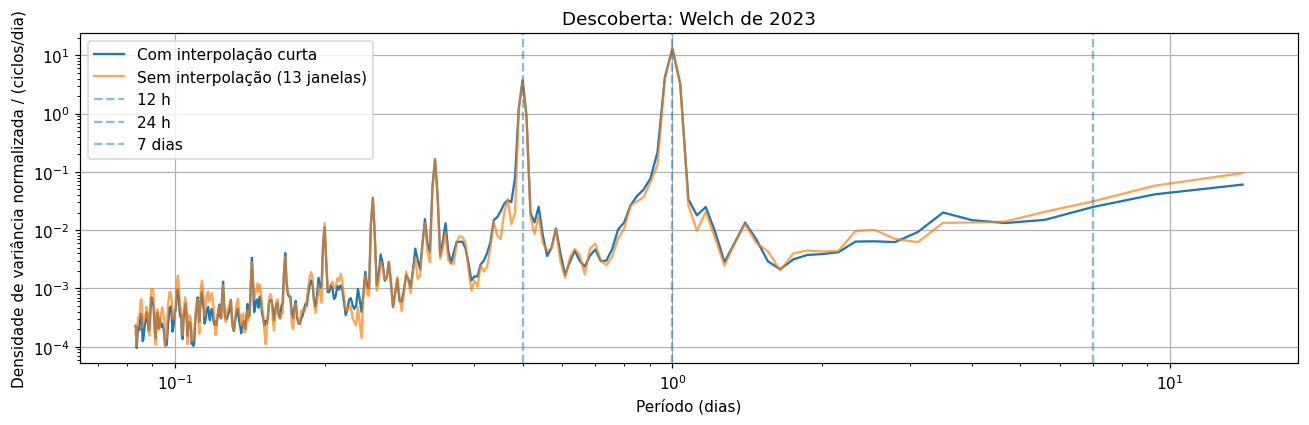

In [ ]:
# ------------------------------------------------------------
# Calcula Welch de 2023, lista candidatos e compara os espectros com e sem interpolação.
# ------------------------------------------------------------

f_t, e_t, centros_t, v_t = espectros_janelas(series_anuais[ANO_TREINO]["horaria"])
if not v_t.any():
    raise ValueError("Nenhuma janela válida no treino.")
psd_t = e_t[:, v_t].mean(axis=1)
candidatos_treino = tabela_picos(f_t, psd_t, 2/24, 14)
resultados_horarios = {ANO_TREINO: {"freq": f_t, "psd": psd_t, "espectros": e_t,
                                   "centros": centros_t, "validas": v_t,
                                   "freq_min": 1/14, "freq_max": 12}}
print(f"{ANO_TREINO}: {v_t.sum()}/{len(v_t)} janelas utilizadas.")
print("Candidatos descobertos exclusivamente no treino:")
display(candidatos_treino.round(4))
f_sem, e_sem, _, v_sem = espectros_janelas(series_anuais[ANO_TREINO]["original"])
m = (f_t >= 1/14) & (f_t <= 12)
fig, ax = plt.subplots()
ax.loglog(1/f_t[m], psd_t[m], label="Com interpolação curta")
if v_sem.any():
    ax.loglog(1/f_sem[m], e_sem[:, v_sem].mean(axis=1)[m], alpha=.7,
              label=f"Sem interpolação ({v_sem.sum()} janelas)")
else:
    print("Sem janelas completas sem interpolação para esta comparação.")
referencias(ax)
ax.set(xlabel="Período (dias)", ylabel="Densidade de variância normalizada / (ciclos/dia)",
       title=f"Descoberta: Welch de {ANO_TREINO}")
ax.legend()
plt.tight_layout()
plt.show()

O resultado mais evidente é que o tráfego apresenta um padrão diário forte: algo na série tende a se repetir a cada 24 horas. Também aparece uma componente de 12 horas, mas ela pode fazer parte da própria forma do ciclo diário, em vez de representar um segundo ciclo independente. Esses dois padrões aparecem tanto com quanto sem a interpolação das pequenas lacunas, o que indica que provavelmente não foram criados pela interpolação. Já o padrão de 7 dias não aparece de forma tão clara neste gráfico.

## 7. Verificação em 2024 dos candidatos descobertos em 2023
Mantemos janela, passo, tratamento e frequências candidatas. A tabela verifica se o mesmo bin é um máximo local em cada ano e compara a fração de potência em uma banda de ±1 bin, relativa à faixa de 2 horas a 14 dias. Bandas podem se sobrepor; seus percentuais não devem ser somados.

Não selecionamos novas frequências a partir de 2024. A persistência de um máximo espectral entre os anos reforça a evidência de que aquela componente de frequência é recorrente na série. Isso não implica, entretanto, que cada máximo corresponda a um ciclo independente, pois alguns candidatos podem representar harmônicas de uma periodicidade fundamental.

Aqui o notebook entra numa etapa conceitualmente diferente da anterior: em 2023 descobrimos os candidatos; em 2024 perguntamos se esses mesmos candidatos continuam aparecendo

2024: 45/49 janelas utilizadas.
2024, sem interpolação: 1/49 janelas válidas.


,periodo_candidato_horas,periodo_bin_2023_horas,maximo_local_2023,potencia_banda_2023_pct,periodo_bin_2024_horas,maximo_local_2024,potencia_banda_2024_pct
0,24.0000,24.0000,True,72.8257,24.0000,True,70.8596
1,12.0000,12.0000,True,20.9951,12.0000,True,19.6984
2,8.0000,8.0000,True,0.9264,8.0000,True,0.9025
3,336.0000,336.0000,True,0.3641,336.0000,False,0.2641
4,6.0000,6.0000,True,0.2008,6.0000,True,0.1457
5,11.2000,11.2000,True,0.3264,11.2000,False,1.0671
6,12.9231,12.9231,True,0.1680,12.9231,False,0.2573
7,28.0000,28.0000,True,0.1880,28.0000,True,0.2416


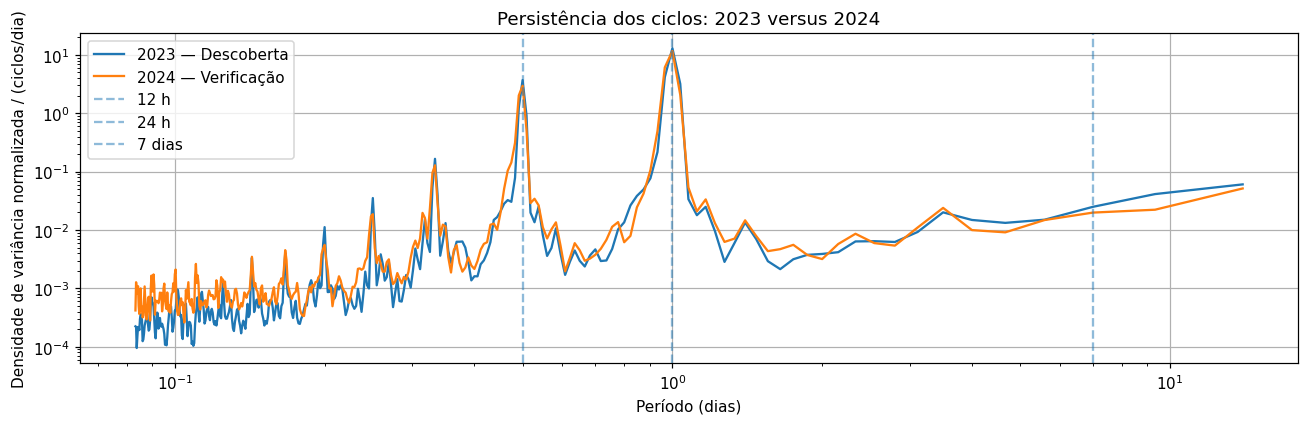

,periodo_horas,psd_2024_com_interpolacao,psd_2024_sem_interpolacao
0,24.0000,11.6338,10.0235
1,12.0000,2.9654,4.8640
2,8.0000,0.1285,0.2625
3,336.0000,0.0516,0.0309
4,6.0000,0.0187,0.0564
5,11.2000,0.1039,0.0381
6,12.9231,0.0265,0.0081
7,28.0000,0.0335,0.0269


In [7]:
# ------------------------------------------------------------
# Compara os candidatos espectrais entre 2023 e 2024 e os efeitos da interpolação em 2024.
# ------------------------------------------------------------

f_v, e_v, centros_v, v_v = espectros_janelas(series_anuais[ANO_VALIDACAO]["horaria"])
if not v_v.any():
    raise ValueError("Nenhuma janela válida na validação.")
psd_v = e_v[:, v_v].mean(axis=1)
assert np.array_equal(f_t, f_v)
resultados_horarios[ANO_VALIDACAO] = {"freq": f_v, "psd": psd_v, "espectros": e_v,
                                     "centros": centros_v, "validas": v_v,
                                     "freq_min": 1/14, "freq_max": 12}
print(f"{ANO_VALIDACAO}: {v_v.sum()}/{len(v_v)} janelas utilizadas.")
comparacao_horaria = comparar_candidatos(candidatos_treino, resultados_horarios)
display(comparacao_horaria.round(4))
fig, ax = plt.subplots()
for ano, r in resultados_horarios.items():
    m = (r["freq"] >= 1/14) & (r["freq"] <= 12)
    ax.loglog(1/r["freq"][m], r["psd"][m], label=f"{ano} — {PAPEIS[ano]}")
referencias(ax)
ax.set(xlabel="Período (dias)", ylabel="Densidade de variância normalizada / (ciclos/dia)",
       title="Persistência dos ciclos: 2023 versus 2024")
ax.legend()
plt.tight_layout()
plt.show()
# Sensibilidade também na verificação, mantendo os mesmos candidatos.
f_sv, e_sv, _, v_sv = espectros_janelas(series_anuais[ANO_VALIDACAO]["original"])
print(f"{ANO_VALIDACAO}, sem interpolação: {v_sv.sum()}/{len(v_sv)} janelas válidas.")
if v_sv.any():
    p_sv = e_sv[:, v_sv].mean(axis=1)
    sensibilidade = candidatos_treino[["periodo_horas"]].copy()
    bins = [np.argmin(abs(f_v-f)) for f in candidatos_treino["frequencia_ciclos_dia"]]
    sensibilidade["psd_2024_com_interpolacao"] = psd_v[bins]
    sensibilidade["psd_2024_sem_interpolacao"] = p_sv[bins]
    display(sensibilidade.round(4))

Resumo dos resultados
A verificação em 2024 mostra que as principais componentes identificadas em 2023 permanecem presentes:
- 24 h: componente dominante nos dois anos, com cerca de 73% da potência em 2023 e 71% em 2024. É a evidência mais forte de sazonalidade recorrente.
- 12 h: também persiste claramente, com aproximadamente 21% e 20% da potência, respectivamente. Pode ser uma harmônica do ciclo diário.
- 8 h e 6 h: permanecem como máximos locais, mas têm potência muito menor e também podem ser harmônicas de 24 h.
- 14 dias (336 h): não permanece como máximo local em 2024 e apresenta pouca potência, portanto há menor evidência de persistência.
- 28 h: continua sendo máximo local, mas representa uma parcela muito pequena da potência.
- 11,2 h e 12,9 h: não permanecem como máximos locais em 2024, apesar de ainda existir potência nessas regiões.
Conclusão principal: o padrão mais estável e relevante é o ciclo diário de 24 h, acompanhado de uma forte componente de 12 h. Os demais candidatos são muito menos expressivos e devem ser interpretados com cautela, especialmente por poderem representar harmônicas ou variações próximas das componentes principais.
A comparação de sensibilidade sem interpolação em 2024 é fraca, pois apenas 1 das 49 janelas é válida sem interpolação.

## 8. Espectrogramas separados: persistência dentro de cada ano

O principal objetivo aqui é verificar se uma periodicidade que aparece forte no espectro médio é persistente ao longo do ano ou se esse pico médio foi produzido apenas por alguns períodos específicos.

Cada coluna representa uma janela de 28 dias, com passo de sete dias. Nenhuma janela atravessa a divisão entre 2023 e 2024. Regiões brancas indicam janelas rejeitadas por lacunas.


Os dois painéis utilizam a mesma escala em dB, referenciada ao maior valor espectral observado em 2023. Valores de 2024 superiores a essa referência são truncados visualmente em 0 dB, devido ao limite superior adotado para a escala.

O valor de 0 dB corresponde ao maior valor espectral encontrado em 2023.
Isso significa, por exemplo:
- 0 dB → mesma intensidade que o máximo de referência de 2023;
- -10 dB → potência 10 vezes menor;
- -20 dB → potência 100 vezes menor;
- -30 dB → potência 1000 vezes menor.
A escala é útil porque a componente de 24 h é muito mais forte que várias outras. Sem a transformação logarítmica, componentes menores poderiam praticamente desaparecer visualmente.


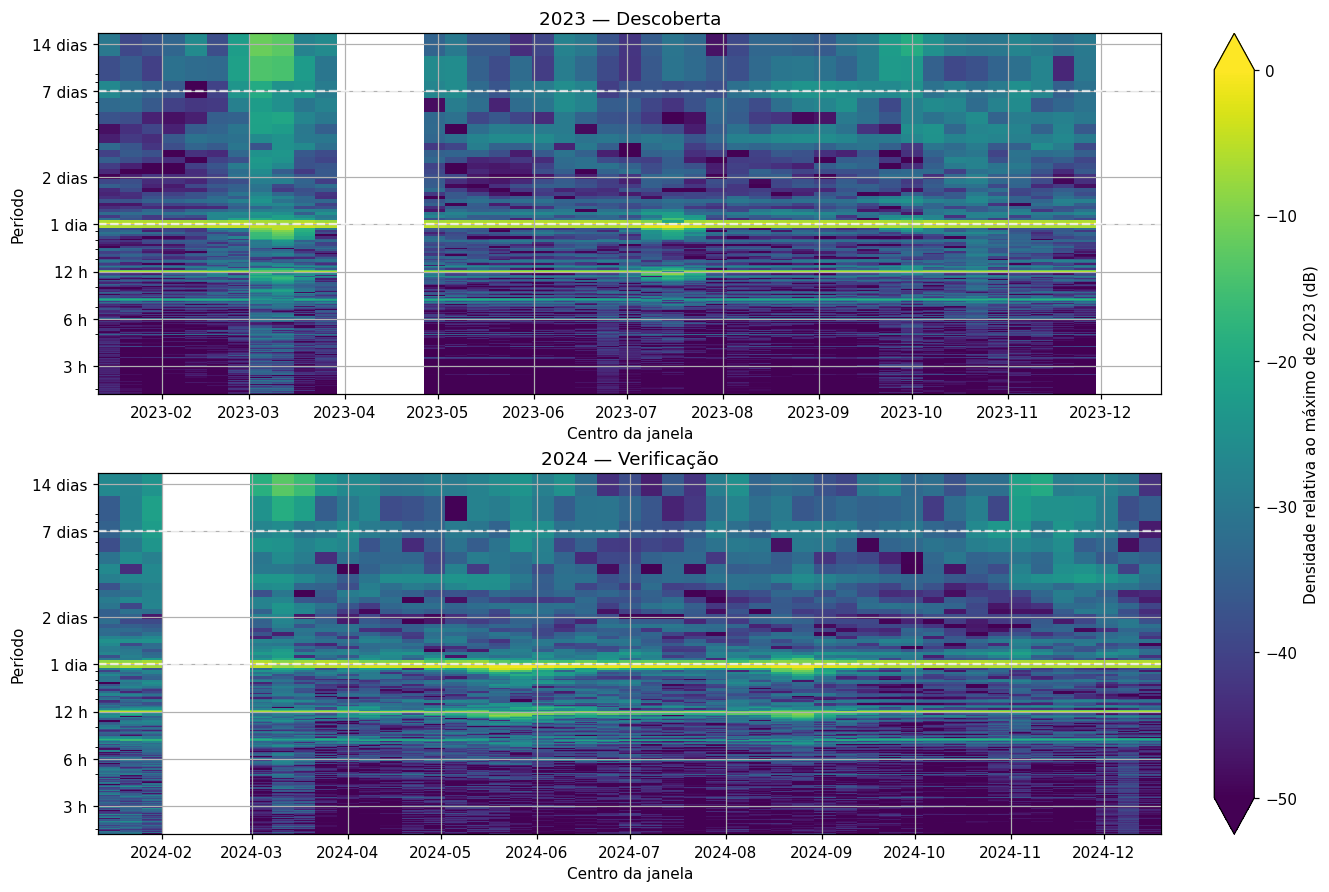

In [8]:
# ------------------------------------------------------------
# Plota os espectrogramas anuais em dB com referência no máximo espectral de 2023.
# ------------------------------------------------------------

m = (f_t >= 1/14) & (f_t <= 12)
periodos = 1/f_t[m]
ordem = np.argsort(periodos)
referencia_treino = max(np.nanmax(e_t[m]), np.finfo(float).tiny)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), layout="constrained")
cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("white")
for ax, ano in zip(axes, ANOS_ANALISE):
    r = resultados_horarios[ano]
    potencia = r["espectros"][m]
    db = 10*np.log10(np.maximum(potencia, np.finfo(float).tiny)/referencia_treino)
    im = ax.pcolormesh(r["centros"], periodos[ordem], np.ma.masked_invalid(db[ordem]),
                       shading="auto", cmap=cmap, vmin=-50, vmax=0)
    ax.set_yscale("log")
    ax.set_yticks([.125, .25, .5, 1, 2, 7, 14], labels=["3 h", "6 h", "12 h", "1 dia", "2 dias", "7 dias", "14 dias"])
    for periodo in [1, 7]:
        ax.axhline(periodo, color="white", linestyle="--", alpha=.7)
    ax.set(title=f"{ano} — {PAPEIS[ano]}", xlabel="Centro da janela", ylabel="Período")
fig.colorbar(im, ax=axes, label="Densidade relativa ao máximo de 2023 (dB)", extend="both")
plt.show()


A característica mais evidente é a faixa horizontal muito intensa em 1 dia (24 h). Ela aparece durante praticamente todas as janelas válidas tanto em 2023 quanto em 2024.
Isso é importante porque mostra que o pico de 24 h observado anteriormente não resulta de alguns poucos períodos do ano. A componente diária é persistente ao longo do tempo.
A componente de 12 h também forma uma faixa relativamente contínua nos dois anos, embora menos intensa que a de 24 h. Isso é consistente com o resultado anterior: 12 h é a segunda componente mais importante e pode ser uma harmônica do ciclo diário.
Já para períodos maiores, especialmente próximos de 7 e 14 dias, a situação é diferente. Há regiões de maior potência em algumas épocas, mas não vemos uma faixa horizontal forte e contínua comparável à de 24 h. Isso reforça a cautela em interpretar essas periodicidades mais longas como ciclos estáveis.
As regiões brancas também contam uma história importante
Elas são bem visíveis:
- em 2023, principalmente aproximadamente entre abril e início de maio, além do final do ano;
- em 2024, principalmente durante parte de fevereiro, além de algumas regiões nas extremidades.
Como cada coluna corresponde a uma janela de 28 dias e as janelas se sobrepõem, uma lacuna relativamente curta nos dados pode invalidar várias janelas consecutivas. Portanto, a largura da região branca no espectrograma não deve ser interpretada diretamente como a duração da lacuna original.

## 9. Máximos diários: descoberta em 2023 e verificação em 2024
Com uma amostra por dia, o ciclo de 24 horas não pode ser identificado. A FFT de descoberta usa o maior trecho contínuo de 2023, exigindo pelo menos 56 dias; examina períodos de 2 dias até um terço do trecho, limitados a 90 dias.

Para comparar os anos com a mesma resolução, usamos também Welch em janelas de 28 dias, com passo de sete dias, agora sobre os máximos diários. Os candidatos são extraídos apenas de 2023, entre 2 e 14 dias, e examinados nos mesmos bins em 2024. **Não interpolamos máximos diários. Aplicamos o critério final de 90% (260/288), definido pela investigação de completude e robustez, mantendo-o fixo na comparação espectral.**

Poucas janelas válidas limitam a representatividade da comparação. Informamos as datas de cada janela utilizada. A análise dos picos é complementar à previsão da série de tráfego e não fornece rótulos de anomalia.

FFT de picos de 2023: 2023-04-11 até 2023-11-09 (213 dias)


,frequencia_ciclos_dia,periodo_dias,periodo_horas,intensidade_espectral
0,0.1455,6.8710,164.9032,0.4230
1,0.1784,5.6053,134.5263,0.3646
2,0.4554,2.1959,52.7010,0.3332
3,0.0939,10.6500,255.6000,0.2964
4,0.4319,2.3152,55.5652,0.2937
5,0.2770,3.6102,86.6441,0.2774
6,0.0516,19.3636,464.7273,0.2665
7,0.2676,3.7368,89.6842,0.2548


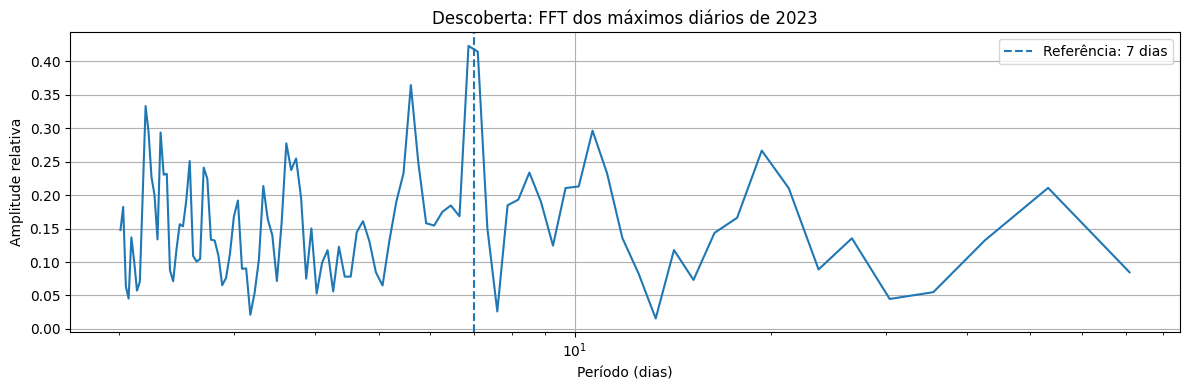

2023: maior trecho diário = 213 dias; Welch = 38/49 janelas.
2024: maior trecho diário = 158 dias; Welch = 33/49 janelas.


,ano,inicio,fim
0,2023,2023-01-01,2023-01-28
1,2023,2023-01-08,2023-02-04
2,2023,2023-01-15,2023-02-11
3,2023,2023-01-22,2023-02-18
4,2023,2023-01-29,2023-02-25
...,...,...,...
66,2024,2024-11-04,2024-12-01
67,2024,2024-11-11,2024-12-08
68,2024,2024-11-18,2024-12-15
69,2024,2024-11-25,2024-12-22


Candidatos diários de 2023 e verificação nos mesmos bins em 2024:


,periodo_candidato_horas,periodo_bin_2023_horas,maximo_local_2023,potencia_banda_2023_pct,periodo_bin_2024_horas,maximo_local_2024,potencia_banda_2024_pct
0,168.0000,168.0000,True,39.1153,168.0000,True,36.3661
1,96.0000,96.0000,True,21.0439,96.0000,False,19.3186
2,67.2000,67.2000,True,17.0531,67.2000,False,21.5350
3,51.6923,51.6923,True,14.3108,51.6923,False,12.8897


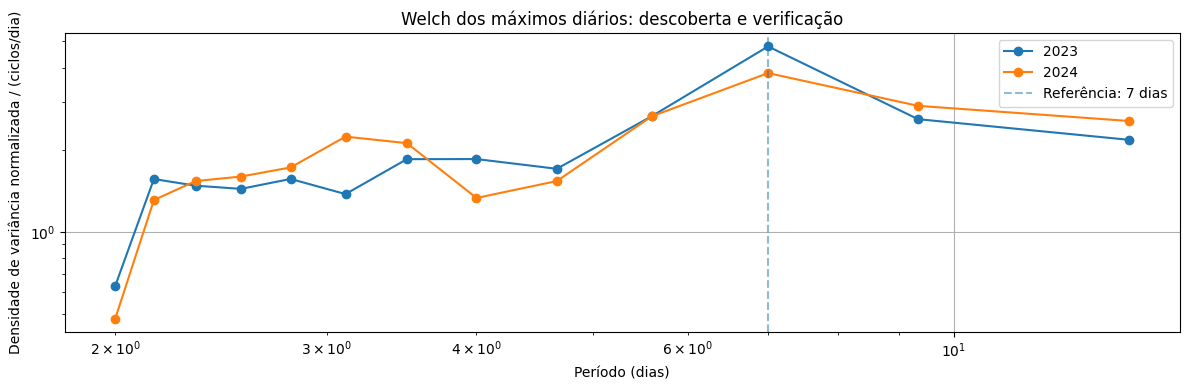

In [ ]:
# ------------------------------------------------------------
# Calcula FFT e Welch dos máximos diários, lista janelas válidas e compara candidatos entre anos.
# ------------------------------------------------------------

trecho_picos_treino = maior_trecho(series_anuais[ANO_TREINO]["picos"])
print(f"FFT de picos de {ANO_TREINO}: {trecho_picos_treino.index.min().date()} até {trecho_picos_treino.index.max().date()} ({len(trecho_picos_treino)} dias)")
if len(trecho_picos_treino) >= 56:
    f_d, a_d = espectro_fft(trecho_picos_treino, 1)
    limite_dias = min(90, len(trecho_picos_treino)/3)
    display(tabela_picos(f_d, a_d, 2, limite_dias).round(4))
    m_d = (f_d >= 1/limite_dias) & (f_d <= .5)
    fig, ax = plt.subplots()
    ax.semilogx(1/f_d[m_d], a_d[m_d])
    ax.axvline(7, linestyle="--", label="Referência: 7 dias")
    ax.set(title=f"Descoberta: FFT dos máximos diários de {ANO_TREINO}", xlabel="Período (dias)", ylabel="Amplitude relativa")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Trecho inferior a 56 dias: FFT de picos não calculada.")

resultados_diarios = {}
janelas_diarias = []
for ano in ANOS_ANALISE:
    s = series_anuais[ano]["picos"]
    f, e, centros, v = espectros_janelas(s, dt_dias=1)
    maior = maior_trecho(s)
    print(f"{ano}: maior trecho diário = {len(maior)} dias; Welch = {v.sum()}/{len(v)} janelas.")
    if not v.any():
        print(f"Sem janelas válidas em {ano}; comparação diária indisponível.")
        continue
    resultados_diarios[ano] = {"freq": f, "psd": e[:, v].mean(axis=1),
                               "freq_min": 1/14, "freq_max": .5}
    for centro in centros[v]:
        inicio = centro - pd.Timedelta(days=JANELA_DIAS//2)
        janelas_diarias.append({"ano": ano, "inicio": inicio.date(),
                                "fim": (inicio + pd.Timedelta(days=JANELA_DIAS-1)).date()})
display(pd.DataFrame(janelas_diarias))
comparacao_diaria = pd.DataFrame()
if set(resultados_diarios) == set(ANOS_ANALISE):
    r_t = resultados_diarios[ANO_TREINO]
    candidatos_diarios_treino = tabela_picos(r_t["freq"], r_t["psd"], 2, 14)
    print("Candidatos diários de 2023 e verificação nos mesmos bins em 2024:")
    comparacao_diaria = comparar_candidatos(candidatos_diarios_treino, resultados_diarios)
    display(comparacao_diaria.round(4))
    fig, ax = plt.subplots()
    for ano, r in resultados_diarios.items():
        m_d = (r["freq"] >= 1/14) & (r["freq"] <= .5)
        ax.loglog(1/r["freq"][m_d], r["psd"][m_d], marker="o", label=str(ano))
    ax.axvline(7, linestyle="--", alpha=.5, label="Referência: 7 dias")
    ax.set(title="Welch dos máximos diários: descoberta e verificação", xlabel="Período (dias)",
           ylabel="Densidade de variância normalizada / (ciclos/dia)")
    ax.legend()
    plt.tight_layout()
    plt.show()

Com o critério diário de 90%, a FFT de 2023 utiliza o maior trecho contínuo de 213 dias, de 2023-04-11 a 2023-11-09. Seu maior pico ocorre em aproximadamente 6,87 dias.

No Welch dos máximos diários, o principal candidato de 2023 é 7,00 dias. A componente de 7 dias apresenta 39,12% da potência na banda em 2023 e 36,37% em 2024; permanece como máximo local em 2024. Esses resultados são evidência espectral exploratória, não demonstração de ganho preditivo. Componentes compatíveis com harmônicas não devem ser tratadas automaticamente como ciclos independentes.


### Cobertura das janelas do Welch dos máximos diários

Com 90% de completude diária, são válidas **38/49 janelas em 2023 e 33/49 em 2024**. Permanecem 3 dias sem máximo válido em 2023 e 19 em 2024. Os maiores trechos diários contínuos têm, respectivamente, 213 e 158 dias.

Cada janela exige 28 máximos diários válidos e avança sete dias. Um único dia rejeitado pode invalidar várias janelas sobrepostas; o total de janelas não corresponde ao total de intervalos independentes. A tabela acima informa as datas utilizadas. A comparação continua restrita aos períodos com cobertura suficiente, e os máximos não são interpolados.

O **Welch horário** conserva 42/49 e 45/49 janelas válidas: sua entrada é a série horária, cujo critério e interpolação não mudaram. O **Welch dos máximos diários** usa `picos` e, portanto, é afetado por `MIN_OBS_DIA`.

Os registros anteriores com 95%, incluindo as 5/49 janelas diárias de 2024, estão identificados como históricos no [notebook auxiliar](03a_daily_completeness_sensitivity.ipynb).


## 10. Síntese calculada
A síntese descreve somente 2023 e 2024. Persistência de máximos locais e de potência nas bandas sugere candidatos a atributos; não demonstra ganho de previsão, causalidade, significância estatística ou suficiência de capacidade. Nenhuma frequência nova é selecionada usando 2024.

In [ ]:
# ------------------------------------------------------------
# Exibe a síntese das janelas válidas, dos principais candidatos e de sua verificação.
# ------------------------------------------------------------

print(f"Descoberta: {ANO_TREINO}. Verificação: {ANO_VALIDACAO}.")
for ano, r in resultados_horarios.items():
    print(f"{ano}: {r['validas'].sum()}/{len(r['validas'])} janelas horárias válidas.")
if not candidatos_treino.empty:
    principal = candidatos_treino.iloc[0]
    linha = comparacao_horaria.iloc[0]
    print(f"Principal candidato horário de 2023: {principal.periodo_horas:.2f} h.")
    print(f"É máximo local no mesmo bin de 2024? {linha[f'maximo_local_{ANO_VALIDACAO}']}")
if not comparacao_diaria.empty:
    linha = comparacao_diaria.iloc[0]
    print(f"Principal candidato de Welch dos picos diários de 2023: {linha.periodo_candidato_horas/24:.2f} dias.")
    print(f"É máximo local no mesmo bin de 2024? {linha[f'maximo_local_{ANO_VALIDACAO}']}")
    print("A comparação diária representa apenas as janelas com cobertura suficiente; consulte suas datas.")
print("Próximo passo: avaliar em 2024 se atributos baseados nos candidatos de 2023 melhoram a previsão.")
print("2025 permanece fora desta análise; janeiro de 2026 será apenas avaliação complementar.")

Descoberta: 2023. Verificação: 2024.
2023: 42/49 janelas horárias válidas.
2024: 45/49 janelas horárias válidas.
Principal candidato horário de 2023: 24.00 h.
É máximo local no mesmo bin de 2024? True
Principal candidato de Welch dos picos diários de 2023: 7.00 dias.
É máximo local no mesmo bin de 2024? True
A comparação diária representa apenas as janelas com cobertura suficiente; consulte suas datas.
Próximo passo: avaliar em 2024 se atributos baseados nos candidatos de 2023 melhoram a previsão.
2025 permanece fora desta análise; janeiro de 2026 será apenas avaliação complementar.


## 11. Implicações para o modelo de previsão
- Prioridade: prever a série temporal de tráfego, avaliar MAE e RMSE e examinar especificamente os erros associados aos picos e à sua eventual subestimação.
- Atributos candidatos: as periodicidades mais consistentes identificadas em 2023, especialmente as componentes diária e semanal, podem orientar atributos temporais, termos seno/cosseno, defasagens e baselines sazonais. Componentes como 12 h e 8 h podem representar harmônicas do ciclo diário e devem ser avaliadas pela contribuição efetiva ao desempenho preditivo, e não apenas pela presença no espectro.
- Seleção e teste: comparar as configurações na validação de 2024. Após a escolha do modelo e dos atributos, retreinar utilizando 2023–2024 e realizar a avaliação final em 2025, conforme o recorte temporal previamente definido.
- Anomalias como complemento: investigar possíveis erros de medição quando houver evidências específicas, sem remover automaticamente valores elevados apenas por sua magnitude. A análise de Fourier não identifica, por si só, observações que devam ser excluídas do treinamento.
A interpolação bilateral e as transformações utilizadas neste notebook têm finalidade exploratória e retrospectiva. No modelo de previsão, cada entrada deve ser construída apenas com informações disponíveis no instante da previsão, e quaisquer transformações ajustáveis devem ser estimadas exclusivamente sobre os dados de treinamento. Não devem ser realizadas interpolações que atravessem as fronteiras entre treino, validação e teste.
A disponibilidade de um ano permite observar repetidamente ciclos diários e semanais, mas não é suficiente para estabelecer uma sazonalidade anual. A verificação em 2024 permanece descritiva e está sujeita às limitações de cobertura e às possíveis mudanças de comportamento entre os períodos.
Capacidade: como a série analisada agrega tráfego de entrada e saída, uma futura avaliação de preparo do PTT exigirá que as previsões sejam comparadas com uma medida de capacidade utilizável compatível em abrangência, direção e unidade, considerando também gargalos e redundâncias da infraestrutura. A análise espectral, isoladamente, não fornece uma probabilidade de saturação.

Análise de observações atípicas: a investigação de valores atípicos pode ser utilizada como apoio à preparação dos dados e à análise dos erros do modelo de previsão, especialmente para distinguir possíveis erros de medição de picos legítimos de tráfego. O objetivo não é desenvolver um modelo de detecção de anomalias, e valores extremos não devem ser removidos apenas por sua magnitude.

**Para o fechamento da revisão do Notebook 03, ficaram estas pendências**:
- Valores iguais a zero: verificar quantidade e localização dos total_gbps = 0 e definir explicitamente seu tratamento, considerando-os possíveis erros de medição.
- Máximos diários × P95/P99: avaliar se o máximo diário é a melhor representação dos picos ou se P95/P99 produz uma medida mais robusta para a análise e para a futura previsão.
- 10 horas ausentes em 2023: localizar e caracterizar essas lacunas e avaliar uma interpolação adicional controlada. Comparar a FFT de uma série próxima ao ano completo com a FFT atual, baseada no maior trecho contínuo de aproximadamente 244 dias.
- Eixo Y dos espectros: revisar a denominação utilizada, avaliando se “Amplitude relativa”, “Amplitude espectral” ou outra denominação representa corretamente a grandeza calculada.
- Sensibilidade sem interpolação em 2024: revisar essa comparação, pois somente 1/49 janelas horárias é válida sem interpolação, tornando a comparação com as 45/49 janelas interpoladas pouco representativa.
- Normalização dos espectrogramas: confirmar em espectros_janelas() se existe efetivamente normalização individual por janela e, a partir disso, corrigir ou manter a afirmação de que a normalização “compara formas, não crescimento absoluto em Gbps”.
- Cobertura dos máximos diários em 2024: com o critério final de 90%, 33/49 janelas são válidas. Considerar a distribuição das janelas e sua sobreposição ao interpretar a componente semanal; os diagnósticos de completude estão no [notebook auxiliar](03a_daily_completeness_sensitivity.ipynb).
- Harmônicas: na redação final, deixar explícito que componentes como 12 h, 8 h e 6 h podem ser harmônicas das 24 h e que 3,5 dias pode ser harmônica dos 7 dias, evitando tratá-las automaticamente como ciclos independentes.
- Observações atípicas: deixar claro o escopo: elas podem ser investigadas para melhorar a preparação dos dados, o treinamento e a análise dos erros de previsão, distinguindo possíveis erros de medição de picos legítimos. Não será desenvolvido um modelo de detecção de anomalias.
- Texto sobre 2025: manter documentado que houve inspeção anterior de 2025, mas preferencialmente registrar isso nas limitações/decisões metodológicas, e não como parte central das implicações para o modelo.
As três primeiras provavelmente são as que mais podem alterar os resultados atuais do notebook; as demais são principalmente verificações metodológicas, de interpretação ou de redação


## Referências de implementação

- [NumPy: FFT e convenções de frequência](https://numpy.org/doc/stable/reference/routines.fft.html).
- [Matplotlib: estimativas espectrais, Welch e espectrograma](https://matplotlib.org/stable/api/mlab_api.html).

As funções usam NumPy, pandas e Matplotlib, sem SciPy. Janelas, normalização e descarte por lacunas estão explícitos no código.